# **EXPLORACIÓN DE DATOS (EDA) — BANCO ATLAS**
- Base de datos: df_original_proyeccion_260511

## **Objetivos**:
- Generen resúmenes estadísticos (media, mediana, desviación estándar, etc.).
- Identificación completa de valores faltantes y uso de técnicas adecuadas para gestionarlos, con una justificación breve de las decisiones tomadas.
- Creen visualizaciones iniciales (histogramas, gráficos de dispersión, diagramas de caja, etc.) para identificar tendencias o anomalías.
- Identificación de outliers en las variables relevantes, con una estrategia de tratamiento aplicada y justificación.
- Detecten correlaciones entre variables.
- Análisis de la distribución de la variable objetivo para identificar desbalance y aplicar, si es necesario, técnicas de balanceo con justificación adecuada.
- Resumen claro y conciso que aborde los hallazgos principales de la EDA y las decisiones tomadas, indicando una visión general del estado de los datos para el modelado.

# Instalación librerias y bibliotecas

In [73]:
! pip install sweetviz

   ---------------------------------------- 0.0/15.1 MB ? eta -:--:--
   -- ------------------------------------- 0.8/15.1 MB 3.4 MB/s eta 0:00:05
   ---- ----------------------------------- 1.8/15.1 MB 4.4 MB/s eta 0:00:03
   ------ --------------------------------- 2.6/15.1 MB 4.2 MB/s eta 0:00:04
   --------- ------------------------------ 3.7/15.1 MB 4.3 MB/s eta 0:00:03
   ---------- ----------------------------- 3.9/15.1 MB 4.4 MB/s eta 0:00:03
   --------------- ------------------------ 5.8/15.1 MB 4.6 MB/s eta 0:00:03
   ------------------- -------------------- 7.3/15.1 MB 4.9 MB/s eta 0:00:02
   ---------------------- ----------------- 8.4/15.1 MB 5.0 MB/s eta 0:00:02
   ---------------------- ----------------- 8.4/15.1 MB 5.0 MB/s eta 0:00:02
   ---------------------- ----------------- 8.4/15.1 MB 5.0 MB/s eta 0:00:02
   ---------------------- ----------------- 8.4/15.1 MB 5.0 MB/s eta 0:00:02
   ----------------------- ---------------- 8.9/15.1 MB 3.4 MB/s eta 0:00:02
   ---


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [74]:
# Manipulación de datos
import pandas as pd
import numpy as np
# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sweetviz as sv
import sys
sys.prefix

c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'c:\\Users\\ADMIN\\AppData\\Local\\Programs\\Python\\Python313'

In [46]:
'''
# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')  
sns.set_palette("husl")          

# Configuración de pandas para visualización completa
pd.set_option('display.max_columns', None)  # Mostrar todas las columnas
pd.set_option('display.max_rows', 100)      # Mostrar hasta 100 filas
pd.set_option('display.float_format', '{:.2f}'.format)  # 2 decimales
'''    

'\n# Configuración de visualización\nplt.style.use(\'seaborn-v0_8-darkgrid\')  \nsns.set_palette("husl")          \n\n# Configuración de pandas para visualización completa\npd.set_option(\'display.max_columns\', None)  # Mostrar todas las columnas\npd.set_option(\'display.max_rows\', 100)      # Mostrar hasta 100 filas\npd.set_option(\'display.float_format\', \'{:.2f}\'.format)  # 2 decimales\n'

# Cargar el dataset

In [64]:
df=pd.read_csv("../../data/df_original_proyeccion_260511.csv")
df


,Periodo,<=25,26-35,36-45,46-55,56-65,65+,Total_pobl,Crecimiento_pobl,Edad_media,Ind_envejecer,Saldo_vegetativo,Saldo_migratorio,Tasa_mortalidad,Tasa_natalidad
0,2026,1.237681e+07,5.779888e+06,6.768906e+06,8.122848e+06,7.034528e+06,9.827273e+06,4.991228e+07,"11,866794","44,711298","153,941008","-2,534351","14,401145","9,276262","6,741911"
1,2027,1.242516e+07,5.912826e+06,6.712990e+06,8.189565e+06,7.172271e+06,1.009326e+07,5.050809e+07,"10,397509","44,888040","159,641397","-2,456478","12,853987","9,255500","6,799022"
2,2028,1.244773e+07,6.029974e+06,6.676138e+06,8.210232e+06,7.319272e+06,1.035060e+07,5.103598e+07,"8,884314","45,075277","165,553194","-2,391228","11,275542","9,247679","6,856451"
3,2029,1.243947e+07,6.126197e+06,6.659930e+06,8.187605e+06,7.461381e+06,1.061479e+07,5.149140e+07,"7,482023","45,273068","171,747256","-2,344531","9,826554","9,258558","6,914027"
4,2030,1.239014e+07,6.232177e+06,6.654064e+06,8.124339e+06,7.582961e+06,1.089239e+07,5.187809e+07,"6,271706","45,479698","177,995952","-2,313756","8,585462","9,286330","6,972574"
5,2031,1.231373e+07,6.340638e+06,6.644113e+06,8.020115e+06,7.688969e+06,1.119488e+07,5.220447e+07,"5,282207","45,692629","184,398327","-2,295819","7,578026","9,329188","7,033369"
6,2032,1.222225e+07,6.439714e+06,6.640249e+06,7.887626e+06,7.808195e+06,1.148087e+07,5.248094e+07,"4,508795","45,908968","190,799344","-2,289001","6,797796","9,386697","7,097696"
7,2033,1.211442e+07,6.534362e+06,6.643870e+06,7.731228e+06,7.927434e+06,1.176475e+07,5.271810e+07,"3,928678","46,125685","197,213161","-2,291601","6,220279","9,457570","7,165969"
8,2034,1.199824e+07,6.616955e+06,6.657672e+06,7.576282e+06,8.016643e+06,1.205778e+07,5.292561e+07,"3,510998","46,339900","202,920685","-2,301535","5,812533","9,539604","7,238069"
9,2035,1.186198e+07,6.717060e+06,6.665055e+06,7.425213e+06,8.101444e+06,1.233896e+07,5.311175e+07,"3,222473","46,549073","207,875033","-2,316932","5,539405","9,630037","7,313105"


# Descripción del dataset:


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Periodo           11 non-null     int64  
 1   <=25              11 non-null     float64
 2   26-35             11 non-null     float64
 3   36-45             11 non-null     float64
 4   46-55             11 non-null     float64
 5   56-65             11 non-null     float64
 6   65+               11 non-null     float64
 7   Total_pobl        11 non-null     float64
 8   Crecimiento_pobl  11 non-null     float64
 9   Edad_media        11 non-null     float64
 10  Ind_envejecer     11 non-null     float64
 11  Saldo_vegetativo  11 non-null     float64
 12  Saldo_migratorio  11 non-null     float64
 13  Tasa_mortalidad   11 non-null     float64
 14  Tasa_natalidad    11 non-null     float64
dtypes: float64(14), int64(1)
memory usage: 1.4 KB


El conjunto contiene **10 registros y 15 columnas** 
Cada registro representa un año
las columnas representan los siguientes atributos:
- **[1-6]**: son rangos de edad y representa los millones de persona por franja de edad
-  **Total_pobl**:
- **Crecimiento_pobl**:
- **Edad_media**:
- **Ind_envejecimiento**: indice de envejecimiento
- **Saldo_vegetativo**: 
- **Saldo_migratorio**: 
- **Tasa_mortalidad**:
- **Tasa_natalidad**: 

Este dataset se armó manualmente con información extraido de la fuente externa del INE, se extrajeron solo las variables que se consideraron importantes dentro del marco de proyeccion poblacion para el sector bancario.



# Información general del dataset:
- Se observa que el dataser esta predominado por dos tipos de elementos: 1. float en las ccolumnas de rangos de edad y 2. object en el resto de columnas. Hay que corregirlo pues todas las variables son numericas.
- Hay que asegurarse que los types de las variables sea coherente con lo que representa cada columna, a simple vista es correcto.
- Maybe periodo ponerlo en int porque son los años de referencia mas no se hará operaciones con ellos.
- a simple vista no hay datos como Unknown o faltantes

## Correccion de types:

In [65]:
cols_a_fix = [
    'Crecimiento_pobl', 'Edad_media', 'Ind_envejecer', 
    'Saldo_vegetativo', 'Saldo_migratorio', 'Tasa_mortalidad', 'Tasa_natalidad']


for col in cols_a_fix:
    
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '.'), errors='coerce')


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Periodo           11 non-null     int64  
 1   <=25              11 non-null     float64
 2   26-35             11 non-null     float64
 3   36-45             11 non-null     float64
 4   46-55             11 non-null     float64
 5   56-65             11 non-null     float64
 6   65+               11 non-null     float64
 7   Total_pobl        11 non-null     float64
 8   Crecimiento_pobl  11 non-null     float64
 9   Edad_media        11 non-null     float64
 10  Ind_envejecer     11 non-null     float64
 11  Saldo_vegetativo  11 non-null     float64
 12  Saldo_migratorio  11 non-null     float64
 13  Tasa_mortalidad   11 non-null     float64
 14  Tasa_natalidad    11 non-null     float64
dtypes: float64(14), int64(1)
memory usage: 1.4 KB


# Calidad de datos:

## Valores faltantes:

In [50]:
df.isnull().mean().sort_values(ascending=False)



Tasa_natalidad      1.0
Saldo_migratorio    1.0
Tasa_mortalidad     1.0
Saldo_vegetativo    1.0
Ind_envejecer       1.0
Edad_media          1.0
Crecimiento_pobl    1.0
65+                 0.0
56-65               0.0
46-55               0.0
36-45               0.0
26-35               0.0
<=25                0.0
Periodo             0.0
Total_pobl          0.0
dtype: float64

Ole, no hay ningun null

## Filas duplicadas:


In [51]:
duplicados = df.duplicated().sum()
print(f"Total de registros duplicados: {duplicados}")
print(f"Porcentaje de duplicados: {(duplicados / len(df)) * 100:.2f}%")

Total de registros duplicados: 0
Porcentaje de duplicados: 0.00%


# Descripción estadística del dataset:

In [52]:
df.describe()

,Periodo,<=25,26-35,36-45,46-55,56-65,65+,Total_pobl,Crecimiento_pobl,Edad_media,Ind_envejecer,Saldo_vegetativo,Saldo_migratorio,Tasa_mortalidad,Tasa_natalidad
count,11.000000,1.100000e+01,1.100000e+01,1.100000e+01,1.100000e+01,1.100000e+01,1.100000e+01,1.100000e+01,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,2031.000000,1.221267e+07,6.318755e+06,6.673754e+06,7.888428e+06,7.660272e+06,1.120317e+07,5.195908e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,3.316625,2.477380e+05,3.319391e+05,3.823352e+04,3.312738e+05,3.803892e+05,9.334341e+05,1.108913e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,2026.000000,1.174949e+07,5.779888e+06,6.640249e+06,7.297656e+06,7.034528e+06,9.827273e+06,4.991228e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,2028.500000,1.205633e+07,6.078085e+06,6.649088e+06,7.653755e+06,7.390326e+06,1.048269e+07,5.126369e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,2031.000000,1.231373e+07,6.340638e+06,6.659930e+06,8.020115e+06,7.688969e+06,1.119488e+07,5.220447e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2033.500000,1.240765e+07,6.575659e+06,6.682220e+06,8.155972e+06,7.972038e+06,1.191127e+07,5.282185e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,2036.000000,1.244773e+07,6.776514e+06,6.768906e+06,8.210232e+06,8.149894e+06,1.261929e+07,5.328317e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Variables numéricas:

In [67]:
# 1. Seleccionar variables numéricas (excluyendo 'id')
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'id' in numeric_cols:
    numeric_cols.remove('id')  # 'id' no es una variable de análisis

print(f"\n Variables numéricas a analizar: {numeric_cols}")


 Variables numéricas a analizar: ['Periodo', '<=25', '26-35', '36-45', '46-55', '56-65', '65+', 'Total_pobl', 'Crecimiento_pobl', 'Edad_media', 'Ind_envejecer', 'Saldo_vegetativo', 'Saldo_migratorio', 'Tasa_mortalidad', 'Tasa_natalidad']


In [68]:
# 6.3. Calcular estadísticos personalizados (media, mediana, moda, desviación)
stats_summary = pd.DataFrame({
    'Variable': numeric_cols,
    'Media': [df[col].mean() for col in numeric_cols],
    'Mediana': [df[col].median() for col in numeric_cols],
    'Moda': [df[col].mode()[0] if not df[col].mode().empty else np.nan for col in numeric_cols],
    'Desv_std': [df[col].std() for col in numeric_cols],
    'Min': [df[col].min() for col in numeric_cols],
    'Max': [df[col].max() for col in numeric_cols],
    'Rango': [df[col].max() - df[col].min() for col in numeric_cols]
})

print(f"\n RESUMEN ESTADÍSTICO:")
display(stats_summary)


 RESUMEN ESTADÍSTICO:


,Variable,Media,Mediana,Moda,Desv_std,Min,Max,Rango
0,Periodo,2.031000e+03,2.031000e+03,2.026000e+03,3.316625e+00,2.026000e+03,2.036000e+03,1.000000e+01
1,<=25,1.221267e+07,1.231373e+07,1.174949e+07,2.477380e+05,1.174949e+07,1.244773e+07,6.982467e+05
2,26-35,6.318755e+06,6.340638e+06,5.779888e+06,3.319391e+05,5.779888e+06,6.776514e+06,9.966261e+05
3,36-45,6.673754e+06,6.659930e+06,6.640249e+06,3.823352e+04,6.640249e+06,6.768906e+06,1.286570e+05
4,46-55,7.888428e+06,8.020115e+06,7.297656e+06,3.312738e+05,7.297656e+06,8.210232e+06,9.125764e+05
5,56-65,7.660272e+06,7.688969e+06,7.034528e+06,3.803892e+05,7.034528e+06,8.149894e+06,1.115367e+06
6,65+,1.120317e+07,1.119488e+07,9.827273e+06,9.334341e+05,9.827273e+06,1.261929e+07,2.792012e+06
7,Total_pobl,5.195908e+07,5.220447e+07,4.991228e+07,1.108913e+06,4.991228e+07,5.328317e+07,3.370892e+06
8,Crecimiento_pobl,6.216493e+00,5.282207e+00,3.025926e+00,3.059665e+00,3.025926e+00,1.186679e+01,8.840868e+00
9,Edad_media,4.570861e+01,4.569263e+01,4.471130e+01,6.868187e-01,4.471130e+01,4.675109e+01,2.039794e+00


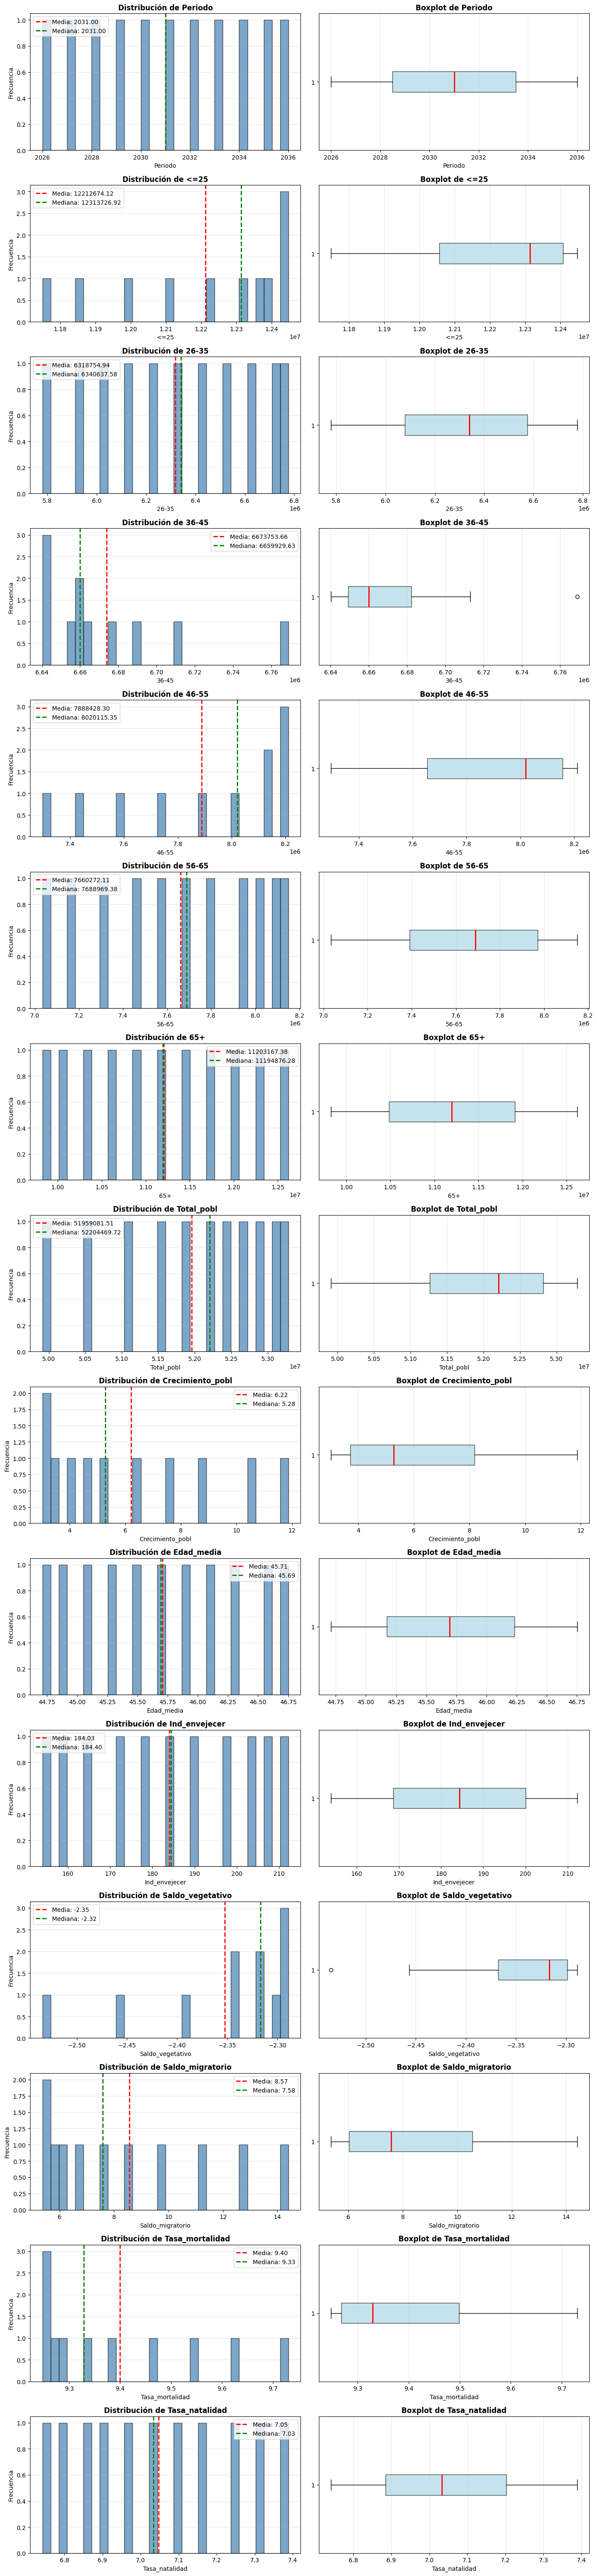

In [69]:
# 3. Visualización de distribuciones: histogramas + boxplots
fig, axes = plt.subplots(nrows=len(numeric_cols), ncols=2, figsize=(14, 4*len(numeric_cols)))

for i, col in enumerate(numeric_cols):
    # Histograma con KDE (distribución suavizada)
    axes[i, 0].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[i, 0].axvline(df[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df[col].mean():.2f}')
    axes[i, 0].axvline(df[col].median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: {df[col].median():.2f}')
    axes[i, 0].set_title(f'Distribución de {col}', fontsize=12, fontweight='bold')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frecuencia')
    axes[i, 0].legend()
    axes[i, 0].grid(axis='y', alpha=0.3)
    
    # Boxplot (detectar outliers)
    axes[i, 1].boxplot(df[col].dropna(), vert=False, patch_artist=True,
                       boxprops=dict(facecolor='lightblue', alpha=0.7),
                       medianprops=dict(color='red', linewidth=2))
    axes[i, 1].set_title(f'Boxplot de {col}', fontsize=12, fontweight='bold')
    axes[i, 1].set_xlabel(col)
    axes[i, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [75]:
# EDA automàtic amb Sweetviz
report = sv.analyze(df)
report.show_html('EDA_report.html')

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:02 -> (00:00 left)


Report EDA_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [70]:
# 4. Detección de outliers (método IQR — Rango Intercuartílico)
print(f"\n DETECCIÓN DE OUTLIERS (Método IQR):")

outliers_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    n_outliers = len(outliers)
    pct_outliers = (n_outliers / len(df)) * 100
    
    outliers_summary.append({
        'Variable': col,
        'N_outliers': n_outliers,
        'Porcentaje': pct_outliers,
        'Límite_inferior': lower_bound,
        'Límite_superior': upper_bound
    })

outliers_df = pd.DataFrame(outliers_summary).sort_values('N_outliers', ascending=False)
display(outliers_df)


 DETECCIÓN DE OUTLIERS (Método IQR):


,Variable,N_outliers,Porcentaje,Límite_inferior,Límite_superior
3,36-45,1,9.090909,6.599391e+06,6.731918e+06
11,Saldo_vegetativo,1,9.090909,-2.471683e+00,-2.194873e+00
1,<=25,0,0.000000,1.152935e+07,1.293462e+07
2,26-35,0,0.000000,5.331725e+06,7.322018e+06
4,46-55,0,0.000000,6.900430e+06,8.909298e+06
5,56-65,0,0.000000,6.517759e+06,8.844606e+06
0,Periodo,0,0.000000,2.021000e+03,2.041000e+03
6,65+,0,0.000000,8.339835e+06,1.405413e+07
7,Total_pobl,0,0.000000,4.892644e+07,5.515910e+07
9,Edad_media,0,0.000000,4.358624e+01,4.782072e+01


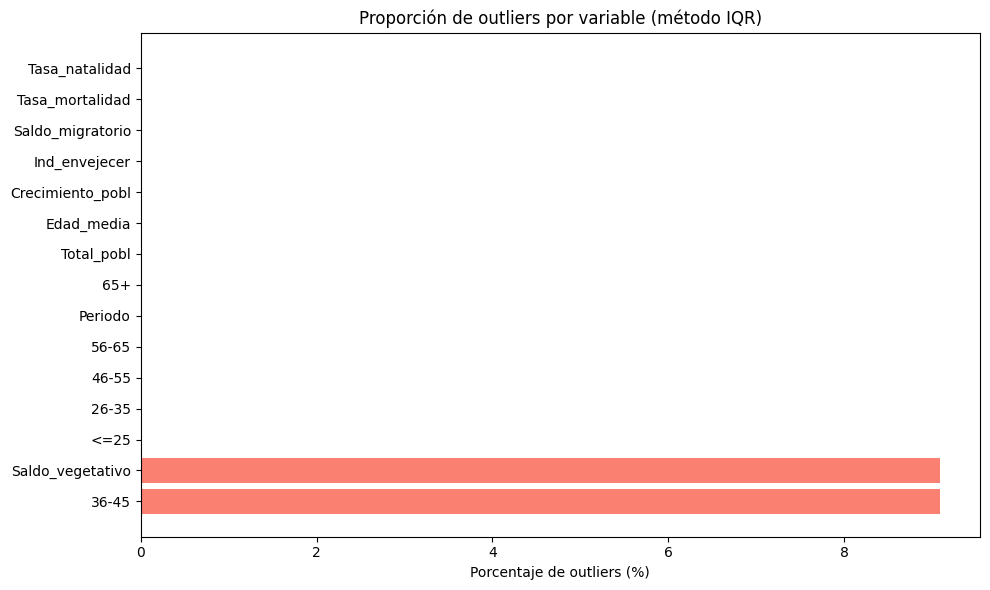

In [71]:
# Visualización de outliers por variable
plt.figure(figsize=(10, 6))
plt.barh(outliers_df['Variable'], outliers_df['Porcentaje'], color='salmon')
plt.xlabel('Porcentaje de outliers (%)')
plt.title('Proporción de outliers por variable (método IQR)')
plt.tight_layout()
plt.show()

- Edad (age): El promedio es de 41 años, con un rango amplio que va desde los 18 hasta los 95 años.  
- Saldo (balance): Existe una alta variabilidad (desviación estándar de 3,225.41). Se observan saldos negativos (mínimo de -6,847) y saldos muy elevados (máximo de 81,204), lo que sugiere la presencia de valores atípicos (outliers).  
- Comportamiento de Campaña: La mediana de contactos por campaña es de 2, pero algunos clientes recibieron hasta 63 contactos.  

Conclusión:
- La distribución del saldo está fuertemente sesgada a la derecha por clientes con altos capitales.
- Es necesario segmentar por rangos de edad y saldo para que los departamentos de Riesgo y Marketing puedan diseñar estrategias diferenciadas.

### ANÁLISIS VARIABLES CATEGÓRICAS

In [58]:
# 1. Seleccionar variables categóricas (tipo 'object')
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols

[]

In [59]:
# 2. Resumen de frecuencias y cardinalidad
cat_summary = []

for col in categorical_cols:
    cat_summary.append({
        'Variable': col,
        'Categorías_únicas': df[col].nunique(),
        'Moda': df[col].mode()[0] if not df[col].mode().empty else 'N/A',
        'Frecuencia_moda': df[col].value_counts().iloc[0],
        'Porcentaje_moda': (df[col].value_counts().iloc[0] / len(df)) * 100
    })

cat_summary_df = pd.DataFrame(cat_summary)
print(f"\n RESUMEN DE VARIABLES CATEGÓRICAS:")
display(cat_summary_df)


 RESUMEN DE VARIABLES CATEGÓRICAS:


""


In [60]:
# 3. Tablas de frecuencias para cada variable categórica
for col in categorical_cols:
    freq_table = df[col].value_counts().reset_index()
    freq_table.columns = ['Categoría', 'Frecuencia']
    freq_table['Porcentaje'] = (freq_table['Frecuencia'] / len(df)) * 100
    
    print(f"\n TABLA DE FRECUENCIAS: {col.upper()}")
    display(freq_table)

    # Gráfico de barras
    plt.figure(figsize=(10, 5))
    plt.bar(freq_table['Categoría'], freq_table['Frecuencia'], color='teal', edgecolor='black', alpha=0.8)
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.title(f'Distribución de {col}', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    

- Perfil Laboral: El cargo más frecuente es management (2,566 clientes).  
- Estado Civil y Educación: La mayoría de los clientes están casados (married) y tienen un nivel educativo de secundaria (secondary).  
- Vivienda y Préstamos: Un alto porcentaje de clientes no tiene deudas de vivienda (housing: no) ni préstamos personales (loan: no).  
- Temporalidad: Mayo es el mes con mayor actividad de contacto (2,824 llamadas).  

Conclusión:
- El cliente típico de Banco Atlas es un profesional administrativo o de gestión, casado, con educación secundaria y libre de deudas personales inmediatas.
- Existe una concentración de las campañas en el mes de mayo.

### ANÁLISIS EXPLORATORIO BIVARIADO (Relaciones entre Variables) - DESAFÍO 3

#### 1. Preparación de Variables Compuestas para el Análisis

In [61]:
# Crear una copia 
df_bivariado = df.copy()

# Convertir variables binarias a numéricas (1: yes, 0: no) para sumar productos
# Productos: loan (préstamo), housing (hipoteca), deposit (depósito)
cols_productos = ['loan', 'housing', 'deposit']
for col in cols_productos:
    df_bivariado[f'{col}_num'] = df_bivariado[col].map({'yes': 1, 'no': 0})

# Calcular el total de productos por cliente
df_bivariado['total_productos'] = df_bivariado[['loan_num', 'housing_num', 'deposit_num']].sum(axis=1)

# Identificar clientes multi-producto (más de 1 producto)
df_bivariado['es_multiproducto'] = df_bivariado['total_productos'] > 1

KeyError: 'loan'

#### 2. RELACIONES DEMOGRÁFICAS × PRODUCTOS FINANCIEROS
Exploración de cómo la ocupación y el nivel educativo se distribuyen según la cantidad de productos contratados.

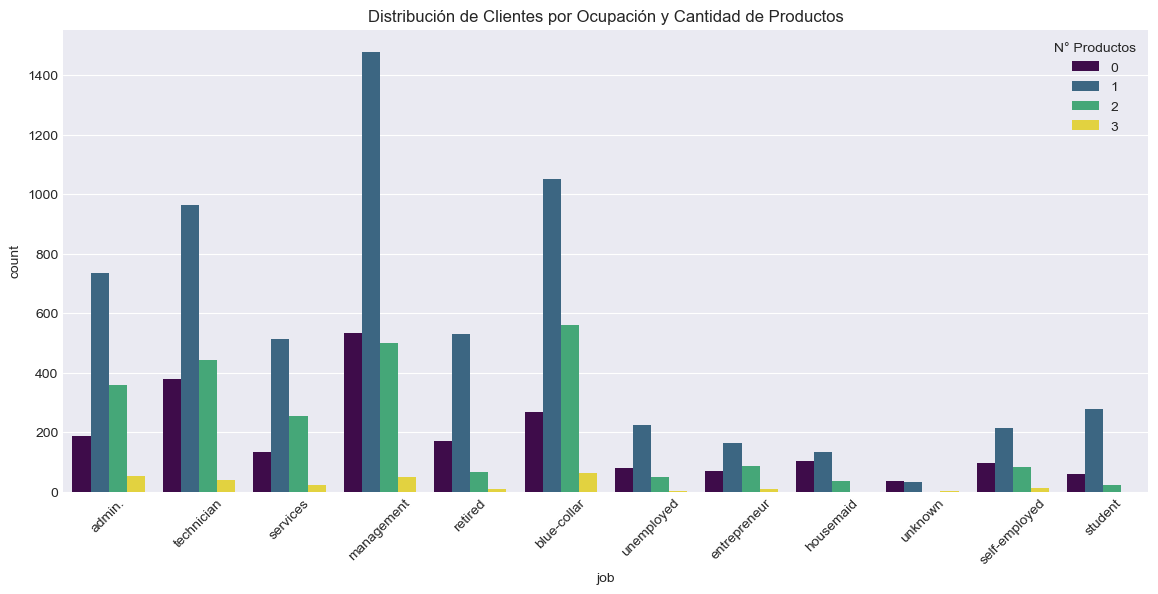

In [ ]:
# 1. Relación Ocupación (job) vs Uso de Múltiples Productos
plt.figure(figsize=(14, 6))
sns.countplot(data=df_bivariado, x='job', hue='total_productos', palette='viridis')
plt.title('Distribución de Clientes por Ocupación y Cantidad de Productos')
plt.xticks(rotation=45)
plt.legend(title='N° Productos', loc='upper right')
plt.show()

In [ ]:
# 2. Tabla de contingencia: Educación vs Cliente Multi-producto
edu_multi_table = pd.crosstab(df_bivariado['education'], df_bivariado['es_multiproducto'], normalize='index') * 100
print("Porcentaje de Clientes Multi-producto por Nivel Educativo:")
display(edu_multi_table)

Porcentaje de Clientes Multi-producto por Nivel Educativo:


es_multiproducto,False,True
education,,
primary,78.13,21.87
secondary,71.94,28.06
tertiary,78.67,21.33
unknown,85.28,14.72


C:\Users\Margot\AppData\Local\Temp\ipykernel_18412\2966838703.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_bivariado, x='total_productos', y='age', palette='Set2')


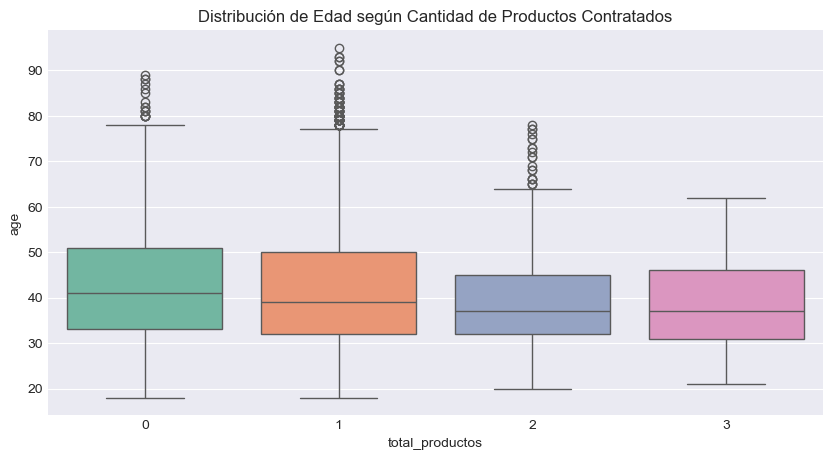

In [ ]:
# 3. Edad vs Total de Productos (Boxplot)
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_bivariado, x='total_productos', y='age', palette='Set2')
plt.title('Distribución de Edad según Cantidad de Productos Contratados')
plt.show()

**Conclusión:**
Se observa que los clientes con niveles de educación superior (tertiary) y cargos en management tienden a contratar el depósito con mayor frecuencia.

#### 3. RELACIONES TEMPORALES × EFECTIVIDAD DE CAMPAÑA
Análisis de la relación entre el momento del contacto (día del mes) y la contratación del depósito.

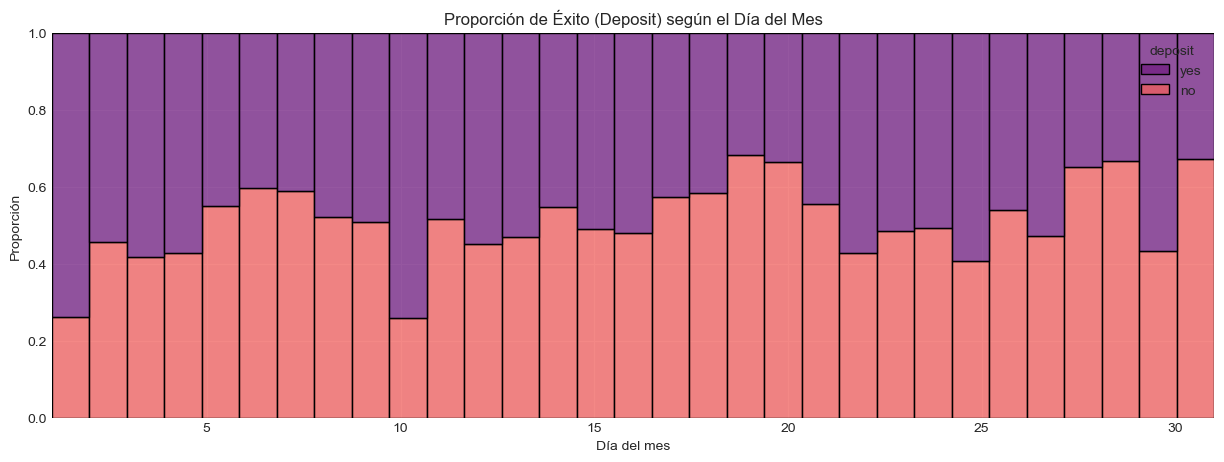

In [ ]:
# 1. Día del mes vs Éxito del Depósito
plt.figure(figsize=(15, 5))
sns.histplot(data=df_bivariado, x='day', hue='deposit', multiple='fill', palette='magma', bins=31)
plt.title('Proporción de Éxito (Deposit) según el Día del Mes')
plt.xlabel('Día del mes')
plt.ylabel('Proporción')
plt.show()

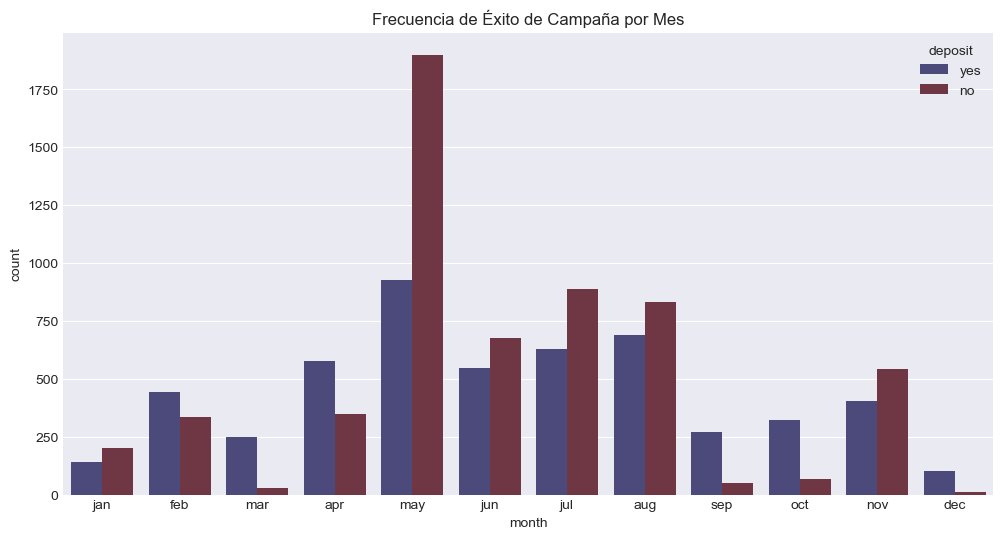

In [ ]:
# 2. Mes vs Éxito del Depósito
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
plt.figure(figsize=(12, 6))
sns.countplot(data=df_bivariado, x='month', hue='deposit', order=month_order, palette='icefire')
plt.title('Frecuencia de Éxito de Campaña por Mes')
plt.show()

**Conclusión:**
La efectividad de la campaña varía según el día del mes (day); los contactos realizados a mitad de mes muestran picos de conversión distintos a los de fin de mes.

#### 4. RELACIONES BALANCE × RIESGO CREDITICIO
Exploración de la relación entre el saldo bancario (balance) y los indicadores de riesgo (default).

C:\Users\Margot\AppData\Local\Temp\ipykernel_18412\1454801974.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_bivariado, x='default', y='balance', jitter=True, alpha=0.5, palette='rocket')


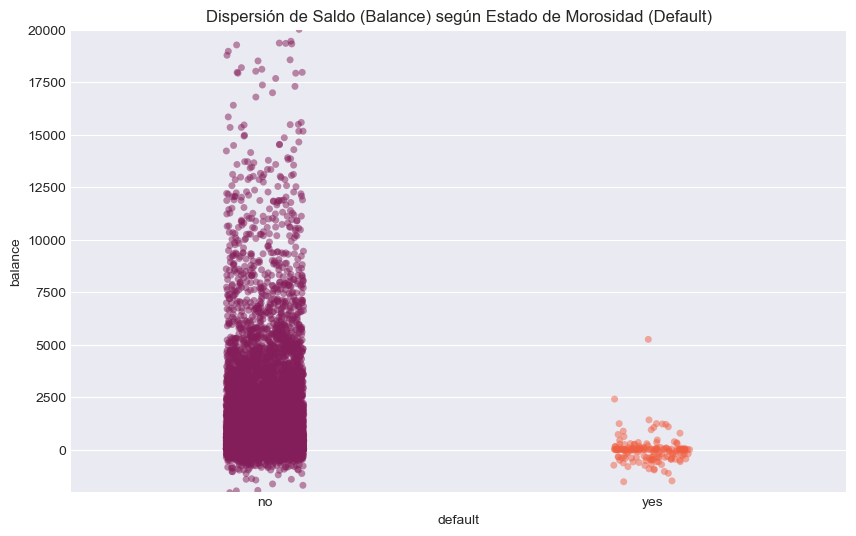

In [ ]:
# 1. Balance vs Default (Riesgo de Morosidad)
plt.figure(figsize=(10, 6))
sns.stripplot(data=df_bivariado, x='default', y='balance', jitter=True, alpha=0.5, palette='rocket')
plt.title('Dispersión de Saldo (Balance) según Estado de Morosidad (Default)')
plt.ylim(-2000, 20000) # Limitamos eje Y para ver mejor la concentración
plt.show()

In [ ]:
# 2. Estadísticos de Balance por categoría de Default
balance_risk_stats = df_bivariado.groupby('default')['balance'].agg(['mean', 'median', 'std', 'min', 'max'])
print("Estadísticos de Saldo (Balance) según Riesgo Crediticio:")
display(balance_risk_stats)

Estadísticos de Saldo (Balance) según Riesgo Crediticio:


,mean,median,std,min,max
default,,,,,
no,1552.84,564.50,3242.32,-3058,81204
yes,-61.80,0.00,827.74,-6847,5249


**Conclusión:**
Los clientes con balance negativo o cercano a cero muestran una tendencia casi nula a contratar depósitos y representan un mayor riesgo de morosidad (default).

**Conclusión General:**

- La estabilidad financiera (saldo positivo) se relaciona fuertemente con la conversión de productos.
- La estrategia de comunicación debe considerar el perfil demográfico: los jóvenes y jubilados responden de manera distinta a los profesionales activos.

### CORRELACIONES Y VISUALIZACIONES GENERALES

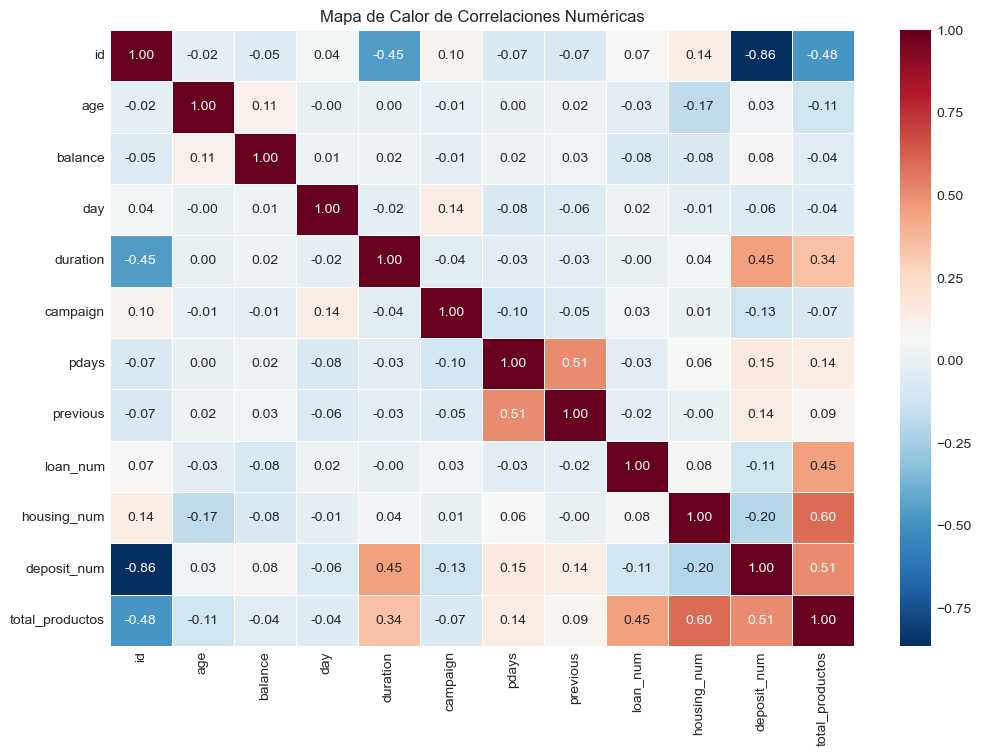

In [ ]:
# Matriz de Correlación de variables numéricas
plt.figure(figsize=(12, 8))
corr_matrix = df_bivariado.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt='.2f', linewidths=0.5)
plt.title('Mapa de Calor de Correlaciones Numéricas')
plt.show()

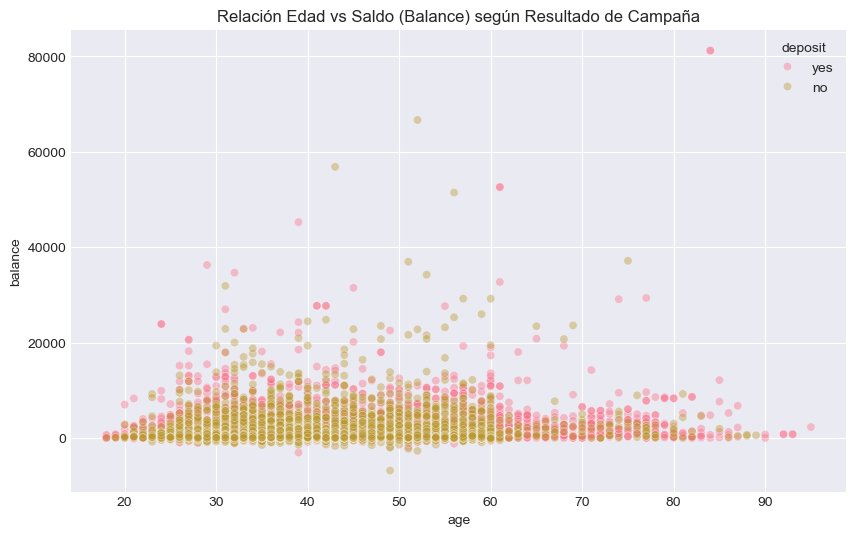

In [ ]:
# Relación Balance vs Edad coloreado por Depósito
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_bivariado, x='age', y='balance', hue='deposit', alpha=0.4)
plt.title('Relación Edad vs Saldo (Balance) según Resultado de Campaña')
plt.show()

- Se identifica una correlación positiva moderada entre la duración de la llamada (duration) y el éxito de la operación (deposit). A mayor tiempo de conversación, mayor probabilidad de éxito.
- No se observan correlaciones lineales fuertes entre variables demográficas y financieras, lo que sugiere que el comportamiento del cliente es multicausal.

#### CONCLUSION

- El dataset presenta una estructura completa y buena calidad de datos, con escasos valores nulos y con una ausencia casi total de duplicados y un nivel de valores nulos inferior al 0.1%, lo que otorga una alta confiabilidad a las inferencias estadísticas presentadas. 
- El análisis revela que el cliente con mayor propensión a la contratación de depósitos es aquel con un perfil profesional de gestión (management), educación terciaria y una situación financiera estable, caracterizada por la ausencia de deudas de vivienda o préstamos personales.
- Existe una correlación positiva entre la duración de la llamada y la conversión, mientras que el contacto excesivo (más de 3-4 veces) no garantiza mejores resultados y puede saturar al cliente.
- Segmentación Financiera: El saldo (balance) actúa como un filtro de viabilidad; los registros con saldos negativos presentan una nula conversión y deben ser tratados bajo estrategias de recuperación o riesgo, no de captación de pasivos.
- Oportunidad Temporal: Mayo destaca como el mes de mayor actividad, siendo una oportunidad que debe ser aprovechada con ofertas personalizadas.

En conjunto, los datos permiten abordar análisis posteriores desde distintas perspectivas de negocio.